# Part 1: A discrete-time model
We have the followong 5 states:

State 1: Post-surgery 
State 2: Local recurrence (Cancer reappears near the removed tumor)   
State 3: Distant metastasis (Cancer appears elsewhere)   
State 4: Both local and distant cancer recurrence   
State 5: Death

We assume we are starting at state 1, the woman just removed the tumor. ($X_0=1)

There is no coming back after reaching state 5 (death)

### Importing necessary packages

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import chisquare

## Task 1

### Setting up the transition matrix

In [2]:
# Defining the transition matrix P
# Rows represent current state, columns represent next state (P[i,j] is the probability of going from state i to state j)
P = np.array([
    [0.9915, 0.005, 0.0025, 0,     0.001], # State 1
    [0,      0.986, 0.005,  0.004, 0.005], # State 2
    [0,      0,     0.992,  0.003, 0.005], # State 3
    [0,      0,     0,      0.991, 0.009], # State 4
    [0,      0,     0,      0,     1    ]  # State 5
])

# Define the states. Making them zero indexed since Python is zero indexed (so 0 corresponds to state 1, 1 to state 2 and so on)
states = [0, 1, 2, 3, 4] # states 1, 2, 3, 4, 5

### Simulating a single woman

In [4]:
# Function to simulate one patients journey
def simulate_patient():
    current_state = 0  # Starts in state 1 (index 0)
    months_survived = 0 # Initial number of months the patient survived
    had_local_recurrence = False    # Initial indicator if local recurrences has happened using boolean value
    
    # We continue simulating until the death state (state 5) is reached
    while current_state != 4:   # Death state is state 5 (index 4)
        # Check if the patient has entered state 2 (local recurrence) at any point
        if current_state == 1:
            had_local_recurrence = True # if state 2 (index 1) was reached at any time change the boolean parameter is changed to True
            
        # Extracting the transition probabilities for the current state
        probabilities = P[current_state]
        
        # Choosing the next state based on the transition probabilities
        next_state = np.random.choice(states, p=probabilities)
        
        # Updating the variables
        current_state = next_state  # The new current state
        months_survived += 1    # Number of months the simulated woman survived
        
    return months_survived, had_local_recurrence

### Scaling to 1000 women

Running the loop for 1000 women and calculating the proportion of women how had local recurrence (reached state 2)

In [5]:
# Setting seed for reproducibility
np.random.seed(2443)

# Define the variables
num_women = 1000 # Number of women we want to simulate for
lifetimes = []      # List to store the months survived for each woman
local_recurrence_count = 0   # Initilize a variable to count how many women had local recurrence (reached state 2)

# Running the simulation 1000 times
for _ in range(num_women):
    months, had_local = simulate_patient()  # The number of months each woman survived for and if she reached state 2
    
    # Storing the results
    lifetimes.append(months)    # Saving the number of month survided for each woman in the list lifetimes
    if had_local:
        local_recurrence_count += 1 # Summing up how many women out of the 100 had local recurrence (reached state 2)

# Calculating the proportion of women who had local recurrence
proportion_local = local_recurrence_count / num_women

print(f"Out of {num_women} women, {local_recurrence_count} experienced local recurrence")
print(f"Proportion: {proportion_local:.4f}")

Out of 1000 women, 585 experienced local recurrence
Proportion: 0.5850


### Plotting a histogram of the lifetime  lifetime distribution of the women

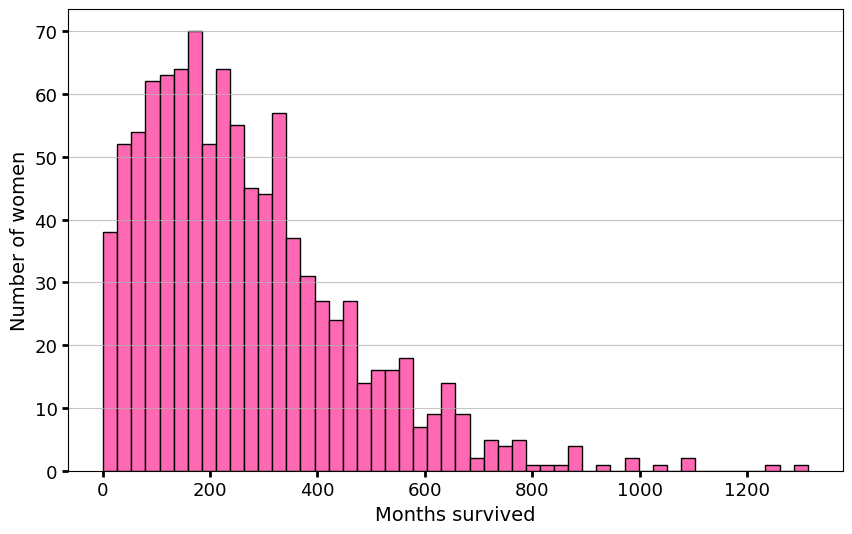

In [15]:
plt.figure(figsize=(10, 6))
plt.hist(lifetimes, bins=50, color='hotpink', edgecolor='black')

# Formatting the plot
#plt.title('Simulated lifetime distribution of 1000 women after tumor removal')
plt.xlabel('Months survived', fontsize=14)
plt.ylabel('Number of women', fontsize=14)
# Making the ticks on the axis larger
plt.tick_params(axis='both', which='major', labelsize=13, length=4, width=2)


# Display the plot
plt.grid(axis='y', alpha=0.75)
plt.show()

The histogram of the simulated lifetimes of the women is highly right-skewed. Which is expected because the probabilities of transitioning into the death state are relatively low early on, many simulated patients will survive for a high number of months, but the count slowly trails off as time goes on.

In [16]:
mean_lifetime = np.mean(lifetimes)
median_lifetime = np.median(lifetimes)

print(f"Mean lifetime: {mean_lifetime}")
print(f"Median lifetime: {median_lifetime}")

Mean lifetime: 267.494
Median lifetime: 229.5


## Task 2
We will look at the distribution over states of our simulations after 120 months ($t=120$). Then we will use a statistical test to check what the distribution should look like after 120 months (what we expect)

In [20]:
# Setting seed for reproducibility
np.random.seed(2443)

# Initializing an array of five elements (all zeros) representing each of the five states.
# Then we will increase the states which the women are at after 120 months
empirical_counts = np.zeros(5)  # Represents how many women are at state: 1,2,3,4,5 at time t=120

# Run 1000 women for 120 months
for _ in range(num_women):
    current_state = 0   # Starting at state 1 (index 0)
    for month in range(120):    # Run for 120 months

        # If they hit state 5 (death, index 4), they stay there
        if current_state == 4:
            break 

        # Choosing the next state based on the transition probabilities
        current_state = np.random.choice(states, p=P[current_state])    

    # Increasing the state after 120 months in the array empirical_counts.
    empirical_counts[current_state] += 1


# Finding the theoretical distribution after 120 months
# Defining the initial state distribution: 100% in state 1, 0% elsewhere
p_0 = np.array([1, 0, 0, 0, 0])

# Raise matrix P to the power of 120
P_120 = np.linalg.matrix_power(P, 120)

# Multiply initial state by P^120 to get probabilities at month 120
p_120 = p_0.dot(P_120)  # p_t = p_0(P^t)

# Multiply by 1000 to get the expected number of women in each state
expected_counts = p_120 * num_women


# Derforming an statistical test: the Chi-Square test
chi_stat, p_value = chisquare(f_obs=empirical_counts, f_exp=expected_counts)


print("The theoretical state distribution for one woman:", p_120)
print("Expected counts after 120 months: ", np.round(expected_counts, 2))
print("Empirical counts after 120 months:", empirical_counts)
print(f"Chi-Square statistic: {chi_stat:.4f}")
print(f"p-value: {p_value:.4f}")

The theoretical state distribution for one woman: [0.35902627 0.15895604 0.1660869  0.06774149 0.2481893 ]
Expected counts after 120 months:  [359.03 158.96 166.09  67.74 248.19]
Empirical counts after 120 months: [347. 172. 181.  66. 234.]
Chi-Square statistic: 3.6683
p-value: 0.4528


The p-value is larger that 0,05. So a null-hypothesis that there is no significant difference between the simulation and the theoretical distribution at time t=120 can not be rejected on a 95% confidence interval. Therefore, the simulations correspond to the expected.

## Task 3
Now we will look at if the simulated lifetime data in task 1 follows the discrete phase-type distribution.

Empirical average lifetime: 267.49 months
Theoretical expected lifetime: 262.37 months


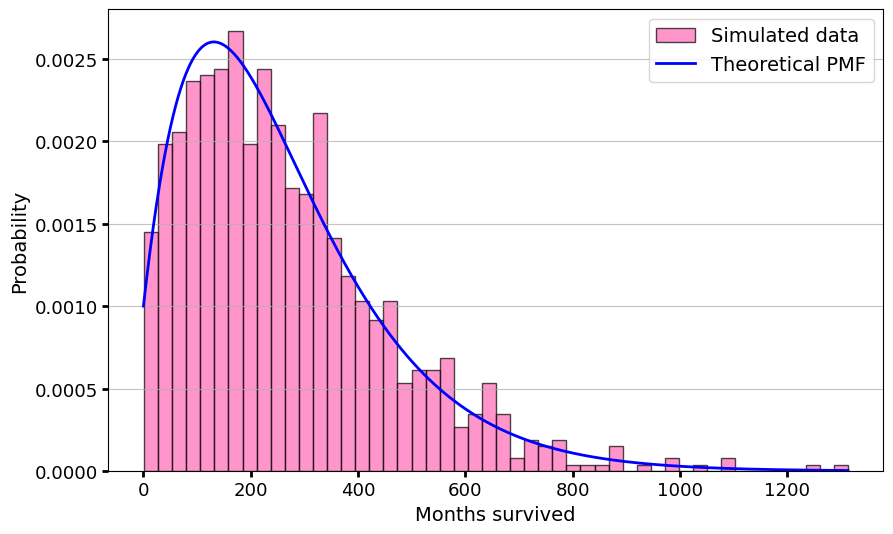

In [24]:
# Setting seed for reproducibility
np.random.seed(2443)

# Defining the parameters

# Extract P_s. A 4x4 submatrix of P, without state 5.
P_s = P[:4, :4] # First 4 rows and  first 4 columns of the probability matrix P

# Extracting p_s. The probability of dying from states 1,2,3,4
p_s = P[:4, 4]  # The first 4 rows of the last column of the ptobability matrix P

# Initial distribution (distribution at time t=0)
pi = np.array([1, 0, 0, 0]) # Always start in state 1

# Defining a vector of ones which we will use in the expectation calculations
ones = np.ones(4)
# Defining an 4x4 identity matrix which we will use in the expectation calculations
I = np.eye(4)

# Calculating the theoretical expected lifetime
inverse_matrix = np.linalg.inv(I - P_s) # (I - P_s)^-1
expected_lifetime = pi.dot(inverse_matrix).dot(ones)    # E(T) = pi * (I - P_s)^-1 * 1

print(f"Empirical average lifetime: {np.mean(lifetimes):.2f} months")
print(f"Theoretical expected lifetime: {expected_lifetime:.2f} months")


# The theoretical distribution
max_t = max(lifetimes)  # Maximum number of months any woman survived
theoretical_pmf = []    # List to store the probabilities P(T=t) for the different t

# Initilizing P_s^t as a 4x4 identity matrix, since P_s^0 is a 4x4 identity matrix
P_s_t = np.eye(4)

# Calculate the probabilities P(T=t) = pi * (P_s)^t * p_s for each month t
for t in range(max_t + 1):  # From 0 to max_t
    if t > 0:   # P_s_t for t=0 is already pre-calculated
        P_s_t = P_s_t.dot(P_s)  # ^t is the same as multiplying by itself t times
    prob = pi.dot(P_s_t).dot(p_s)   # P(T = t) = pi * (P_s)^t * p_s
    theoretical_pmf.append(prob)    # Appending the probabilities to the list


# Plotting the simulated data as histogram and the theoretical pmf on the same plot
plt.figure(figsize=(10, 6))

# Plot empirical histogram (density=True to convert counts to probabilities)
plt.hist(lifetimes, bins=50, density=True, color='hotpink', edgecolor='black', alpha=0.7, label='Simulated data')

# Overlay theoretical PMF as a line
plt.plot(range(max_t + 1), theoretical_pmf, color='blue', lw=2, label='Theoretical PMF')

#plt.title('Simulated lifetime distribution vs theoretical')
plt.xlabel('Months survived', fontsize=14)
plt.ylabel('Probability', fontsize=14)

# Making the ticks on the axis larger
plt.tick_params(axis='both', which='major', labelsize=13, length=4, width=2)


plt.legend(fontsize=14)
plt.grid(axis='y', alpha=0.75)
plt.show()

Notice that the empirical result (simulated mean=267.49) is remarkably close to the theoretical expectation (262.27). Less than 2% difference.

### Chi-square test

In [ ]:
# Converting the list of individual lifetimes into an array where the index is the month, 
# and the value is the number of women who died that month.
empirical_counts = np.bincount(lifetimes, minlength=max_t + 1)  # minlength ensures the array goes all the way to the maximum month observed.

# Converting the theoretical probabilities into expected number of women
expected_counts = np.array(theoretical_pmf) * num_women    # multiply the probability of dying in month 't' by the total number of simulated women (1000)


# Initialize lists to store our new grouped categories (bins).
# We do this because the chi-square test requires at least 5 expected observations per category to be valid.
binned_empirical = [] 
binned_expected = []


# Initilize parameters to track the cumulative sums as we loop through the months
current_emp_sum = 0
current_exp_sum = 0

# Using zip() to iterate through both the simulated counts and the theoretical counts at the exact same time
for emp, exp in zip(empirical_counts, expected_counts):
    current_emp_sum += emp  # summing the empirical counts together
    current_exp_sum += exp  # summing the expected (theoretical) counts together
    
    # When the expected count is atleast 5 we lock it in the bin and save the current count.
    if current_exp_sum >= 5:
        binned_empirical.append(current_emp_sum)
        binned_expected.append(current_exp_sum)

        # Reset the trackers for the next bin
        current_emp_sum = 0
        current_exp_sum = 0

# If there are less than 5 expected women left at the tail after the loop, we add them to the valid bin
if current_exp_sum > 0: 
    binned_empirical[-1] += current_emp_sum
    binned_expected[-1] += current_exp_sum


# Normalizing the expected bins so they sum exactly to our empirical total (1000).
scale_factor = np.sum(binned_empirical) / np.sum(binned_expected)
binned_expected = np.array(binned_expected) * scale_factor

# Running the chi-square test using chisquare from the package scipy.stats 
chi_stat, p_value = chisquare(f_obs=binned_empirical, f_exp=binned_expected)


# Printing the results
print("\nChi-square goodness-of-fit test:")
print(f"Original number of months: {len(empirical_counts)}")
print(f"Number of grouped bins used: {len(binned_empirical)}")
print(f"Test statistic: {chi_stat:.4f}")
print(f"P-value: {p_value:.4f}")


Chi-Square Goodness-of-Fit Test:
Original number of months (categories): 1314
Number of safely grouped bins used: 173
Chi-Square Statistic: 151.1033
P-value: 0.8728


The p-value is 0.8728 > 0.05. Therefore we fail to reject the null hypothesis. Indicating that there is no statistically significant difference between the simulated and the theoretical lifetimes.

## Task 4
We estimate the expected lifetime of a woman who survives the first 12 months after surgery and whose breast cancer has reappeared within the first 12 months, either locally or distant.

Using rejection sampling we will simulate a number of women and discard the simulations which do not meet the requirements (survived the first 12 months and the cancer reappered within the first 12 months). We keep doing this until we have reached 1000 accepted simulation.


In [25]:
# Setting seed for reproducibility
np.random.seed(2443)

accepted_lifetimes = [] # Initilize an empty list to store the number of months the women fulfilling the requirements survive
required_samples = 1000 # The number of 1000 acceptable simulations we want to reach

# Keep looping until our list of accepted simulations (women fulfilling the requirements) reaches 1000
while len(accepted_lifetimes) < required_samples:
    
    current_state = 0  # Start in state 1 (index 0)
    months = 0  # Initialize the number of months a woman has survived   
    recurrence_within_12_months = False # Boolean value for if the cancer has recurred within 12 months
    
    # Run this inner while loop until the woman dies (reaches state 5, index 4)
    while current_state != 4:   # While the woman is alive
        # Move forward one month
        current_state = np.random.choice(states, p=P[current_state])  # Choosing the next state based on the transition probabilities
        months += 1 # Updating the months the woman survived
        
        # Checking if the cancer recurred within the first 12 months
        if months <= 12:
            # If they enter state index 1, 2, or 3, the cancer has reappeared
            if current_state in [1, 2, 3]:
                recurrence_within_12_months = True  # Changing the boolean value to True if the cancer reappeared, this requirement is fulfilled
                
    # Apply the rejection sampling conditions:
    # Condition 1: Survived more than 12 months (months > 12)
    # Condition 2: Cancer reappeared within the first 12 months
    if months > 12 and recurrence_within_12_months:
        accepted_lifetimes.append(months)   # Adding the number of months the women, fulfilling both requirements, survive to the list
        
# The results
expected_lifetime_task4 = np.mean(accepted_lifetimes)   # The mean lifetime of the women fulfilling both requirements

print(f"Number of accepted simulations: {len(accepted_lifetimes)}") # Should be 1000
print(f"Estimated expected lifetime: {expected_lifetime_task4:.2f} months")

Number of accepted simulations: 1000
Estimated expected lifetime: 169.98 months


## Task 5
We will find the fraction of women that die within the first 350 months. Then we will look at the reduction in variance when using control variates instead of crude Monte Carlo.

In [ ]:
num_replications = 100  # Running it 100 times
n_women = 200   # Simulating 200 women

# Initializing empty lists to store the crude Monto Carlo estimates and the control variate
X_list = [] # X_i: The crude Monte Carlo estimates (the fraction dying within the first 350 months)
Z_list = [] # Z_i: The control variate (mean lifetime of the 200 women)


# Simulating 200 women 100 times
for _ in range(num_replications):  # 100 repetitions 
    lifetimes_200 = []  # Empty list to store the lifetimes of the 200 simulated women
    dead_before_350 = 0 # Count how many women die within the first 350 months
    
    # Simulate 200 women
    for _ in range(n_women):
        current_state = 0   # Starting in state 1 (index 0)
        months = 0  # Initial number of survived months for each woman
        
        # Repeating this loop until the woman die
        while current_state != 4:  # While not dead
            current_state = np.random.choice(states, p=P[current_state])  # Choosing the next state based on the transition probabilities
            months += 1 # Updating the number of survived months
            
        lifetimes_200.append(months)    # Appending the lifetime for each woman to the list
        
        # Checking if the women died within the first 350 months
        if months <= 350:   # If they survived less than 350 months (died with the first 350 months)
            dead_before_350 += 1    # Updating the count of how many died within the first 350 months, if they died
            
    # Calculate X_i (crude Monte Carlo)
    X_i = dead_before_350 / n_women # The fraction that died within 350 months
    X_list.append(X_i)  # Appending to the list
    
    # Calculate Z_i (Control variate)
    Z_i = np.mean(lifetimes_200)    # The mean lifetime of the women after surgery
    Z_list.append(Z_i)  # Appending to the list

# Converting the lists to numpy arrays
X = np.array(X_list)
Z = np.array(Z_list)

# The known theoretical mean (from task 3)
mu_Z = expected_lifetime 


# Finding the optimal constant c
c = - ( (np.cov(X, Z)[0, 1]) / (np.var(Z, ddof=1))) # c = - Cov(X_i, Z_i) / V[Z_i] (from day 4, slide 21)

# Calculating the new random variables Y_i
Y = X + c * (Z - mu_Z)  # Y_i = X_i + c * (Z_i - mu_Z) (from day 4, slide 20)

# Calculating the final estimators
theta_hat_MC = np.mean(X)   # The crude Monte Carlo estimator (average of the X_i observations)
theta_hat_CV = np.mean(Y)   # The control variate estimator (average of the Y_i observations)


### Comparing the results

In [ ]:
# Calculating the variances
var_X = np.var(X, ddof=1)   # The variance of the crude Monte Carlo estimator
var_Y = np.var(Y, ddof=1)   # The variance of the control variate estimator

# Calculating the percentage reduction in variance
variance_reduction = ((var_X - var_Y) / var_X) * 100

# Printing the results
print("\n Variance reduction results:")
print(f"Crude Monte Carlo variance (V[X]): {var_X:.6f}")
print(f"Control variate variance (V[Y]):   {var_Y:.6f}")
print(f"Variance reduction:                {variance_reduction:.2f}%")

print("\nThe final estimates:")
print(f"Crude Monte Carlo expected fraction:    {theta_hat_MC:.4f}")
print(f"Control variate expected fraction:      {theta_hat_CV:.4f}")


 Variance reduction results:
Crude Monte Carlo variance (V[X]): 0.001046
Control variate variance (V[Y]):   0.000382
Variance reduction:                63.46%

 The final estimates:
Crude Monte Carlo expected fraction:    0.7383
Control variate expected fraction:      0.7387
